In [233]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [234]:
def display(img,cmap="gray"):
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img,cmap="gray")

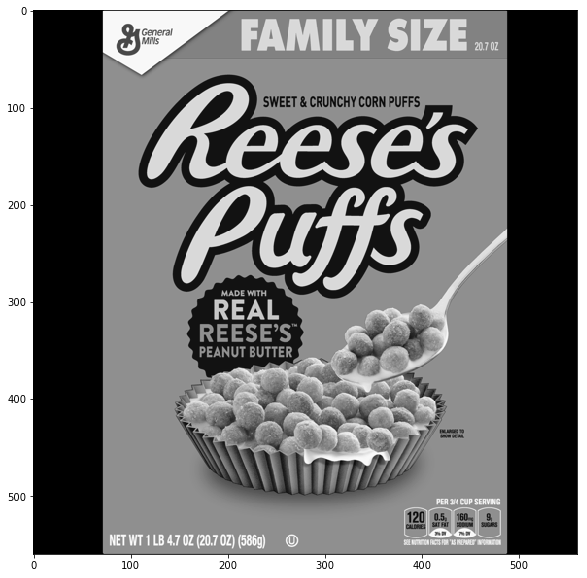

In [235]:
reeses=cv2.imread("DATA/reeses_puffs.png",0)
display(reeses)

In [236]:
cereals=cv2.imread("DATA/many_cereals.jpg",0)

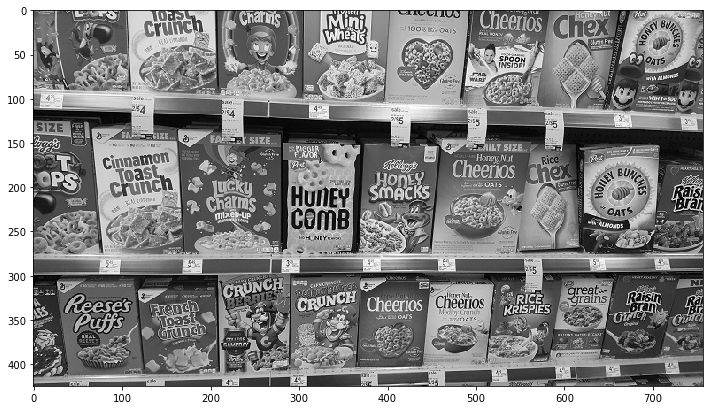

In [237]:
display(cereals)

In [238]:
orb= cv2.ORB_create()

In [239]:
kp1, des1=orb.detectAndCompute(reeses,None)
kp2, des2=orb.detectAndCompute(cereals,None)

In [240]:
bf=cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)

In [241]:
matches=bf.match(des1,des2)

In [242]:
matches=sorted(matches,key=lambda x:x.distance)

In [243]:
reeses_matches=cv2.drawMatches(reeses,kp1,cereals,kp2,matches[:25],None,flags=2)

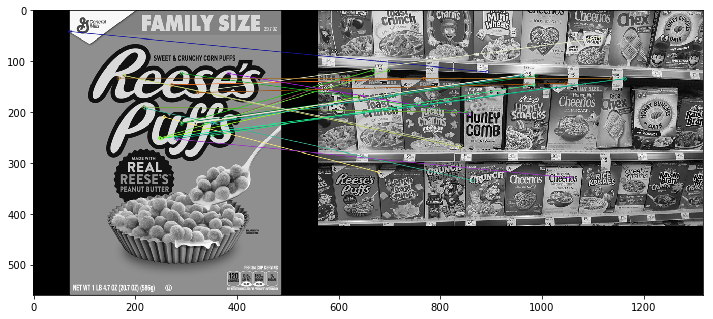

In [244]:
display(reeses_matches)

In [245]:
sift=cv2.xfeatures2d.SIFT_create() #for diffrent scale

In [246]:
kp1, des1=sift.detectAndCompute(reeses,None)

In [247]:
kp2, des2=sift.detectAndCompute(cereals,None)

In [248]:
bf=cv2.BFMatcher()

In [249]:
matches=bf.knnMatch(des1,des2,k=2)

In [250]:
good= []
#less distance better
#ratio test
for match1,match2 in matches:
    if match1.distance<0.75*match2.distance:
        good.append([match1])
    

In [251]:
sift_matches=cv2.drawMatchesKnn(reeses,kp1,cereals,kp2,good,None,flags=2)

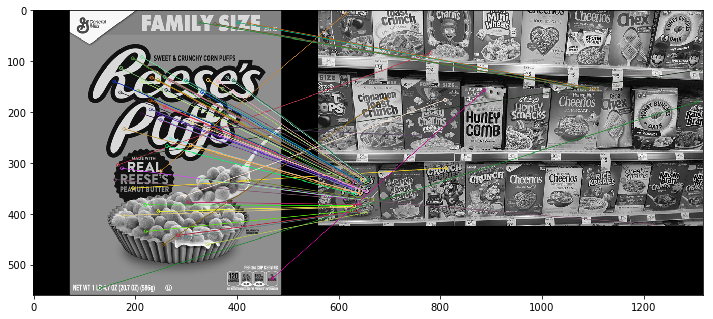

In [252]:
display(sift_matches)

In [253]:
sift=cv2.xfeatures2d.SIFT_create()

In [254]:
kp1, des1=sift.detectAndCompute(reeses,None)
kp2, des2=sift.detectAndCompute(cereals,None)

In [255]:
#FLANN FAST BUT NOT ACCURATE

In [256]:
FLANN_INDEX_KDTREE=0
index_params=dict(algorithm=FLANN_INDEX_KDTREE,trees=5)
search_params=dict(checks=50)

In [257]:
flann=cv2.FlannBasedMatcher(index_params,search_params)

In [258]:
matches= flann.knnMatch(des1,des2,k=2)

In [259]:
matchesMask=[[0,0] for i in range(len(matches))]

In [260]:


for i,(match1,match2) in enumerate(matches):
    if match1.distance<0.7*match2.distance:
        
        matchesMask[i]=[1,0]
    

In [261]:
draw_params=dict(matchColor=(0,255,0),singlePointColor=(255,0,0),matchesMask=matchesMask,flags=0) #flags 2 for only line

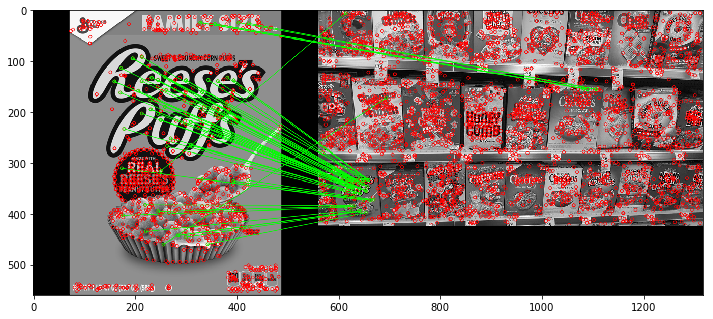

In [262]:
flann_matches=cv2.drawMatchesKnn(reeses,kp1,cereals,kp2,matches,None,**draw_params)
display(flann_matches)